<a href="https://colab.research.google.com/github/feranmii-dev/Final-Year-Project-Machine-Learning-Based-Diagnostic-Models-from-Ophthalmological-Data/blob/main/lcdi_glaucoma_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LCDI — Glaucoma Model
Run top to bottom (Shift+Enter). Data loads straight from Google Drive, and the training table is anonymised (patients appear only as P-#### codes).


### 1. Install libraries


In [1]:
!pip install scikit-learn pandas numpy matplotlib -q


### 2. Data source
The data is pulled from Google Drive automatically — no upload needed.

**Make sure the Drive file is shared as "Anyone with the link."** To use a different file, change `FILE_ID` in the next cell (it's the part of the share link between `/d/` and `/view`).


### 3. Imports & config


In [3]:
# =============================================================================
#  LCDI - Glaucoma classification from digitized ophthalmology records
#  Final-year project.  Run:  python lcdi_glaucoma_model.py
#  Needs: pandas numpy scikit-learn matplotlib   (reads the LCDi1.csv export)
#  The training table is ANONYMISED: patients appear only as P-#### codes;
#  name and hospital number never enter it.
# =============================================================================
import re, numpy as np, pandas as pd
import matplotlib.pyplot as _plt_backend  # Colab shows plots inline
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import (roc_auc_score, accuracy_score, confusion_matrix,
                             classification_report, roc_curve)

# ---- Data source: a CSV on Google Drive (no re-upload each session) ----------
# The Drive file must be shared as "Anyone with the link".
# FILE_ID is the part of the share link between /d/ and /view:
#   https://drive.google.com/file/d/<FILE_ID>/view
FILE_ID  = "1NGIqH7y2Z1XmlrFRHvCMkBSitxmCGr73"
DATA_URL = f"https://drive.google.com/uc?id={FILE_ID}"
# Recommended: upload the ANONYMISED file (LCDi1_anon.csv) to Drive and put its
# id here, so names never enter Colab at all.


### PART 1 - LOAD THE DATA (pandas)


In [5]:
# -----------------------------------------------------------------------------
# PART 1 - LOAD THE DATA (pandas)
# One line pulls the CSV straight from Drive into a DataFrame called `raw`.
# -----------------------------------------------------------------------------
raw = pd.read_csv(DATA_URL)
print("Data loaded:", raw.shape[0], "rows x", raw.shape[1], "columns")
# Tip: run  raw.head()  /  raw.describe()  /  raw.info()  in a cell to explore it.


Data loaded: 346 rows x 26 columns


### PART 2 - FEATURE ENGINEERING (clean whole columns at once)


In [6]:
# -----------------------------------------------------------------------------
# PART 2 - FEATURE ENGINEERING (clean whole columns at once)
# Raw cells are text ("0; -1; 1; 0; -4", "3/36 (8%)", "V.good"). A model only
# eats numbers, so we convert each column, then anonymise, then filter.
# -----------------------------------------------------------------------------
QUALITY = {"V.good": 4, "Good": 3, "Average": 2, "Bad": 1, "V.bad": 0}  # ordinal

def num(colname):                       # a whole column -> numbers (bad cells -> NaN)
    return pd.to_numeric(raw[colname], errors="coerce")

def pct(colname):                       # "3/36 (8%)" -> 8.0, for the whole column
    return raw[colname].astype(str).str.extract(r"\((\d+)%\)", expand=False).astype(float)

# split the hemifield string "0; -1; 1; 0; -4" into five numeric columns
ght = (raw["CVF Glaucoma Hemifield Test [dB]"].astype(str)
         .str.replace(" ", "", regex=False)      # "0;-1;1;0;-4"
         .str.split(";", expand=True)            # one column per number
         .reindex(columns=range(5))              # force exactly 5 columns
         .apply(pd.to_numeric, errors="coerce"))
ght.columns = ["ght1", "ght2", "ght3", "ght4", "ght5"]

# grab any identifier columns ONLY to build the anon key (they may be absent
# already if the file is the anonymised one - handle both cases).
def opt(colname):                       # column if present, else all-missing
    return raw[colname] if colname in raw.columns else np.nan

# assemble one clean table
clean = pd.DataFrame({
    "name_raw":  opt("Name"),                    # used only to build the anon key
    "unit_raw":  opt("Unit No"),                 # used only to build the anon key
    "anon_id":   opt("Anonymous ID"),            # if the file is already anonymised
    "glaucoma":  raw["Glaucoma"],
    # ---- CVF features (the data you digitized) ----
    "avg_dev":   num("CVF Average Deviation dB"),
    "pat_dev":   num("CVF Pattern Deviation dB"),
    "lost_fix":  pct("CVF Lost Fixation % (RE)"),
    "false_pos": pct("CVF False Positive %"),
    "false_neg": pct("CVF False Negative % (RE)"),
    "lf_qual":   raw["CVF Lost Fixation Quality"].map(QUALITY),
    # ---- clinical features (already in your sheet) ----
    "age": num("Age (years)"),
    "cdr": num("Optic Disc Cup to Disc Ratio (CDR)"),
    "iop": num("Intraocular Pressure mmHg (IOP)"),
    "cct": num("Average Central Corneal Thickness um (P - Scan )"),
})
clean = pd.concat([clean, ght], axis=1)

# keep only real, labelled eyes; drop aborted/blank tests
# (a "real" row has a name, or - in the anonymised file - an anonymous id)
if clean["name_raw"].notna().any():
    has_record = clean["name_raw"].notna() & (clean["name_raw"].astype(str).str.strip() != "")
else:
    has_record = clean["anon_id"].notna()
labelled = has_record & clean["glaucoma"].notna()
aborted  = (clean["avg_dev"] == 0) & clean[["ght1","ght2","ght3","ght4","ght5"]].fillna(0).eq(0).all(axis=1)
clean = clean[labelled & ~aborted].copy()

# TARGET: glaucoma yes/no -> 1/0  (works whether the cell is True/False, 1/0, or "yes")
clean["y"] = clean["glaucoma"].map(
    lambda v: 1 if str(v).strip().lower() in ("true", "1", "1.0", "yes") else 0)

# ANONYMISE the grouping key. If the file already has an Anonymous ID, use it;
# otherwise derive a "P-0001" code from hospital-no/name. Either way the real
# name and hospital number are DROPPED and never used again.
if clean["anon_id"].notna().mean() > 0.9:
    clean["patient"] = clean["anon_id"].astype(str)
else:
    def keyify(row):
        u = row["unit_raw"]
        if pd.notna(u) and str(u).strip() != "":
            try:    return str(int(float(u)))                   # hospital number
            except: return str(u).strip()
        return re.sub(r"\s*\(.*?\)\s*|\s+[RL]E?$", "", str(row["name_raw"])).strip().lower()
    real_key = clean.apply(keyify, axis=1)
    codes    = {k: f"P-{i+1:04d}" for i, k in enumerate(dict.fromkeys(real_key))}
    clean["patient"] = real_key.map(codes)

CVF_FEATURES  = ["avg_dev","pat_dev","ght1","ght2","ght3","ght4","ght5",
                 "lost_fix","false_pos","false_neg","lf_qual"]
CLIN_FEATURES = ["age","cdr","iop","cct"]

# final ANONYMISED table: patient code + target + features only (no name / unit no)
df = clean[["patient","y"] + CVF_FEATURES + CLIN_FEATURES].reset_index(drop=True)
assert not ({"Name","Unit No","name_raw","unit_raw"} & set(df.columns)), "identifier leaked!"

print("Labelled, non-aborted eyes:", len(df),
      "| patients:", df.patient.nunique(),
      "| glaucoma/normal:", dict(df.y.value_counts()))
df.head()      # in Colab this displays the first rows of the anonymised table


Labelled, non-aborted eyes: 156 | patients: 93 | glaucoma/normal: {1: np.int64(81), 0: np.int64(75)}


,patient,y,avg_dev,pat_dev,ght1,ght2,ght3,ght4,ght5,lost_fix,false_pos,false_neg,lf_qual,age,cdr,iop,cct
0,P-0001,1,-5.55,6.47,-2.0,1.0,-10.0,-6.0,1.0,15.0,12.0,19.0,2.0,23.0,0.85,12.0,518.0
1,P-0001,1,-3.97,5.89,-3.0,-1.0,6.0,2.0,5.0,13.0,4.0,28.0,2.0,23.0,0.70,11.0,521.0
2,P-0002,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54.0,NaN,NaN,NaN
3,P-0002,1,-10.52,8.19,0.0,0.0,1.0,-8.0,0.0,16.0,4.0,4.0,2.0,54.0,0.80,32.0,566.0
4,P-0003,1,-7.01,2.45,0.0,-2.0,-2.0,1.0,2.0,14.0,17.0,3.0,3.0,35.0,0.65,19.0,536.0


In [7]:
# ---- missing-data handling ----
# 1. how much is missing?  (know these numbers for your defense)
print("\nMissing values per feature:")
print(df[CVF_FEATURES + CLIN_FEATURES].isna().mean().round(2).sort_values(ascending=False))

# 2. drop rows where EVERY feature is missing (structural blanks like P-0002 eye)
all_features = CVF_FEATURES + CLIN_FEATURES
df = df[df[all_features].notna().any(axis=1)].reset_index(drop=True)

# 3. drop feature columns that are >60% empty (too sparse to impute honestly)
too_sparse = [c for c in all_features if df[c].isna().mean() > 0.60]
if too_sparse:
    print("Dropping columns >60% empty:", too_sparse)
CVF_FEATURES  = [c for c in CVF_FEATURES  if c not in too_sparse]
CLIN_FEATURES = [c for c in CLIN_FEATURES if c not in too_sparse]

# 4. the remaining gaps are filled by the median IMPUTER inside the CV pipeline
#    (Part 3) - done per training fold, so no information leaks into the test fold.
print("Rows after cleaning:", len(df))


Missing values per feature:
cct          0.50
lost_fix     0.47
false_neg    0.47
false_pos    0.47
ght1         0.46
ght3         0.46
ght2         0.46
lf_qual      0.46
ght4         0.46
ght5         0.46
pat_dev      0.44
avg_dev      0.44
iop          0.26
cdr          0.06
age          0.06
dtype: float64
Rows after cleaning: 154


### PART 3 - HONEST EVALUATION  (the part examiners probe)


In [8]:
# -----------------------------------------------------------------------------
# PART 3 - HONEST EVALUATION  (the part examiners probe)
# GroupKFold: every patient is wholly in train OR test, never both. A plain
# split would leak a patient's second eye and inflate scores. We report AUC +
# accuracy + confusion matrix, not accuracy alone.
# -----------------------------------------------------------------------------
def evaluate(features, title):
    d = df.dropna(subset=["y"]).copy()
    d = d[d[features].notna().any(axis=1)]             # rows with some feature present
    X, y, g = d[features].values, d["y"].values, d["patient"].values
    cv = GroupKFold(n_splits=min(5, len(np.unique(g))))
    print(f"\n=== {title}  (n={len(d)} eyes, {d.patient.nunique()} patients) ===")
    results = {}
    for model, name in [
        (LogisticRegression(max_iter=2000, class_weight="balanced"), "LogReg"),
        (RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                random_state=0), "RandomForest")]:
        pipe = Pipeline([("impute", SimpleImputer(strategy="median")),
                         ("scale",  StandardScaler()),
                         ("model",  model)])
        proba = cross_val_predict(pipe, X, y, cv=cv, groups=g, method="predict_proba")[:, 1]
        pred  = (proba >= 0.5).astype(int)
        auc   = roc_auc_score(y, proba)
        print(f"  {name:13} accuracy={accuracy_score(y,pred):.3f}  AUC={auc:.3f}")
        results[name] = (y, proba)
    print("  confusion matrix [[TN FP][FN TP]]:", confusion_matrix(y, pred).tolist())
    return results

res_cvf  = evaluate(CVF_FEATURES,               "CVF-only (your digitized data)")
res_all  = evaluate(CVF_FEATURES+CLIN_FEATURES, "CVF + clinical")
res_clin = evaluate(CLIN_FEATURES,              "Clinical-only (sanity check)")



=== CVF-only (your digitized data)  (n=87 eyes, 58 patients) ===
  LogReg        accuracy=0.483  AUC=0.491
  RandomForest  accuracy=0.529  AUC=0.530
  confusion matrix [[TN FP][FN TP]]: [[14, 25], [16, 32]]

=== CVF + clinical  (n=154 eyes, 92 patients) ===
  LogReg        accuracy=0.591  AUC=0.564
  RandomForest  accuracy=0.468  AUC=0.457
  confusion matrix [[TN FP][FN TP]]: [[29, 44], [38, 43]]

=== Clinical-only (sanity check)  (n=154 eyes, 92 patients) ===
  LogReg        accuracy=0.565  AUC=0.588
  RandomForest  accuracy=0.403  AUC=0.460
  confusion matrix [[TN FP][FN TP]]: [[21, 52], [40, 41]]


### PART 4 - WHY THE SCORE IS WHAT IT IS  (diagnostic plots for the defense)



Saved: fig1_signs_by_group.png, fig2_pca.png, fig3_roc.png


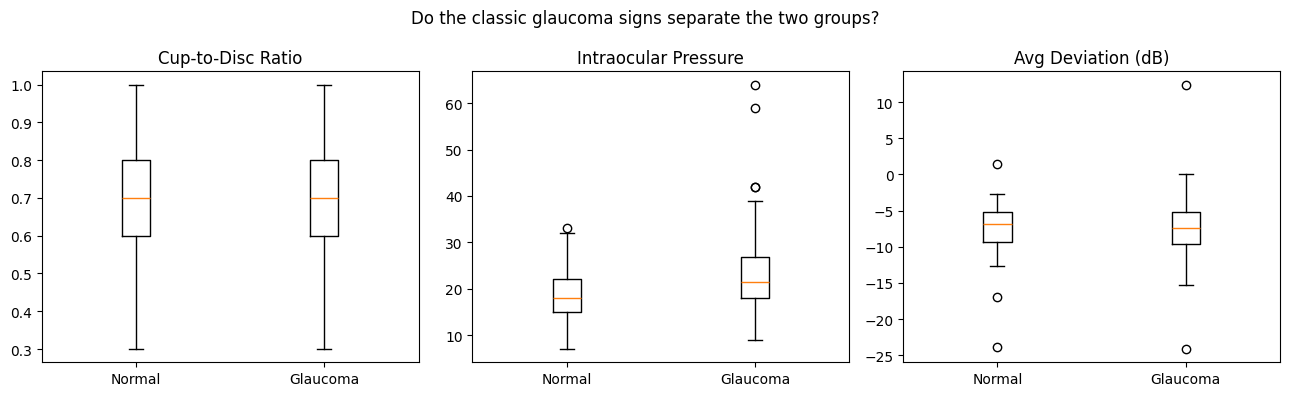

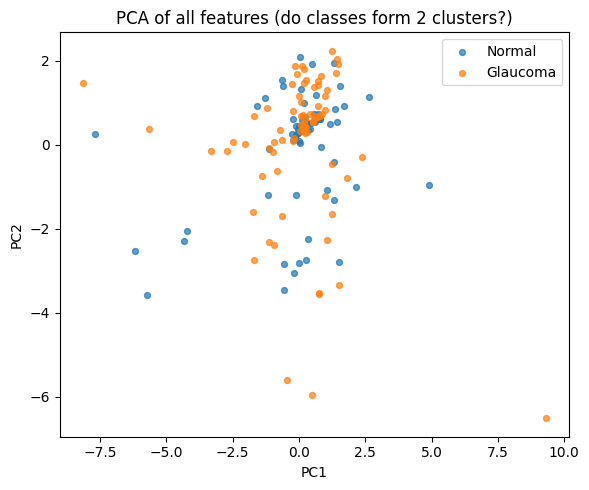

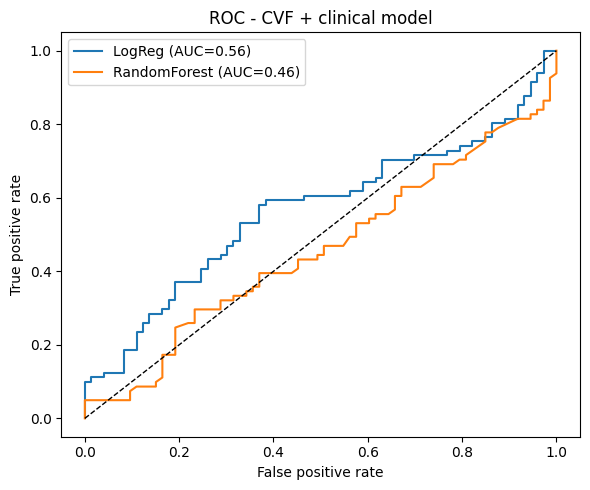

In [9]:
# -----------------------------------------------------------------------------
# PART 4 - WHY THE SCORE IS WHAT IT IS  (diagnostic plots for the defense)
# -----------------------------------------------------------------------------
def boxes(ax, feat, title):
    grp = [df[df.y==0][feat].dropna(), df[df.y==1][feat].dropna()]
    ax.boxplot(grp); ax.set_xticks([1,2]); ax.set_xticklabels(["Normal","Glaucoma"]); ax.set_title(title)

fig, ax = plt.subplots(1, 3, figsize=(13,4))
boxes(ax[0], "cdr", "Cup-to-Disc Ratio")
boxes(ax[1], "iop", "Intraocular Pressure")
boxes(ax[2], "avg_dev", "Avg Deviation (dB)")
fig.suptitle("Do the classic glaucoma signs separate the two groups?")
fig.tight_layout(); fig.savefig("fig1_signs_by_group.png", dpi=130)

d = df.dropna(subset=["y"]).copy()
Xp = SimpleImputer(strategy="median").fit_transform(d[CVF_FEATURES+CLIN_FEATURES])
Xp = StandardScaler().fit_transform(Xp)
pcs = PCA(n_components=2).fit_transform(Xp)
fig2, a2 = plt.subplots(figsize=(6,5))
for lab,c,m in [(0,"tab:blue","Normal"),(1,"tab:red","Glaucoma")]:
    a2.scatter(pcs[d.y.values==lab,0], pcs[d.y.values==lab,1], s=18, alpha=.7, label=m)
a2.set_title("PCA of all features (do classes form 2 clusters?)")
a2.set_xlabel("PC1"); a2.set_ylabel("PC2"); a2.legend()
fig2.tight_layout(); fig2.savefig("fig2_pca.png", dpi=130)

fig3, a3 = plt.subplots(figsize=(6,5))
for name,(yt,pr) in res_all.items():
    fpr,tpr,_ = roc_curve(yt,pr)
    a3.plot(fpr,tpr,label=f"{name} (AUC={roc_auc_score(yt,pr):.2f})")
a3.plot([0,1],[0,1],"k--",lw=1); a3.set_xlabel("False positive rate")
a3.set_ylabel("True positive rate"); a3.set_title("ROC - CVF + clinical model"); a3.legend()
fig3.tight_layout(); fig3.savefig("fig3_roc.png", dpi=130)

print("\nSaved: fig1_signs_by_group.png, fig2_pca.png, fig3_roc.png")


In [10]:
import matplotlib.pyplot as plt
plt.show()


In [11]:
# ============================================================
#  EXTRA ANALYSIS — univariate AUCs, complete-case models, imputation
#  (reuses df, CVF_FEATURES, CLIN_FEATURES from the cells above)
# ============================================================
from sklearn.impute import KNNImputer
from sklearn.metrics import roc_auc_score

# --- 1. Univariate AUC per feature (complete cases only) ---
print("Univariate AUC (higher value = glaucoma; mean-deviation sign flipped):")
for f in ["iop", "cct", "pat_dev", "avg_dev", "cdr", "age"]:
    dd = df.dropna(subset=[f, "y"])
    if dd["y"].nunique() < 2:
        continue
    score = dd[f] if f != "avg_dev" else -dd[f]     # more-negative MD = worse
    print(f"  {f:8} n={len(dd):3}  AUC={roc_auc_score(dd['y'], score):.3f}")

# --- 2. Complete-case logistic-regression models (no imputation) ---
def cc_auc(features):
    dd = df.dropna(subset=features + ["y"])
    X, y, g = dd[features].values, dd["y"].values, dd["patient"].values
    cv = GroupKFold(n_splits=min(5, dd["patient"].nunique()))
    pipe = Pipeline([("sc", StandardScaler()),
                     ("m", LogisticRegression(max_iter=2000, class_weight="balanced"))])
    proba = cross_val_predict(pipe, X, y, cv=cv, groups=g, method="predict_proba")[:, 1]
    return roc_auc_score(y, proba), len(dd), dd["patient"].nunique()

print("\nComplete-case logistic regression (patient-grouped CV):")
for name, feats in [("IOP+CDR+Age",            ["iop", "cdr", "age"]),
                    ("Clinical + core CVF",    ["iop", "cdr", "age", "avg_dev", "pat_dev"])]:
    auc, n, p = cc_auc(feats)
    print(f"  {name:20} AUC={auc:.3f}  (n={n} eyes, {p} patients)")

# --- 3. Median vs KNN imputation on the full feature set ---
print("\nImputation comparison (full feature set, LogReg):")
allf = CVF_FEATURES + CLIN_FEATURES
X, y, g = df[allf].values, df["y"].values, df["patient"].values
cv = GroupKFold(n_splits=5)
for imp, label in [(SimpleImputer(strategy="median"), "median"),
                   (KNNImputer(n_neighbors=5), "KNN-5")]:
    pipe = Pipeline([("imp", imp), ("sc", StandardScaler()),
                     ("m", LogisticRegression(max_iter=2000, class_weight="balanced"))])
    proba = cross_val_predict(pipe, X, y, cv=cv, groups=g, method="predict_proba")[:, 1]
    print(f"  {label:8} AUC={roc_auc_score(y, proba):.3f}")

Univariate AUC (higher value = glaucoma; mean-deviation sign flipped):
  iop      n=115  AUC=0.645
  cct      n= 78  AUC=0.638
  pat_dev  n= 87  AUC=0.553
  avg_dev  n= 87  AUC=0.528
  cdr      n=146  AUC=0.500
  age      n=146  AUC=0.355

Complete-case logistic regression (patient-grouped CV):
  IOP+CDR+Age          AUC=0.586  (n=109 eyes, 57 patients)
  Clinical + core CVF  AUC=0.668  (n=56 eyes, 29 patients)

Imputation comparison (full feature set, LogReg):
  median   AUC=0.564
  KNN-5    AUC=0.550
